# Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón
## Contexto del Problema
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados.

Se cuenta con dos variables de entrada:

* Puntaje Crediticio (Normalizado de 0 a 1).

* Ratio de Ahorro (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un Perceptrón Simple en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

## Paso 1: Preparación del Entorno
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

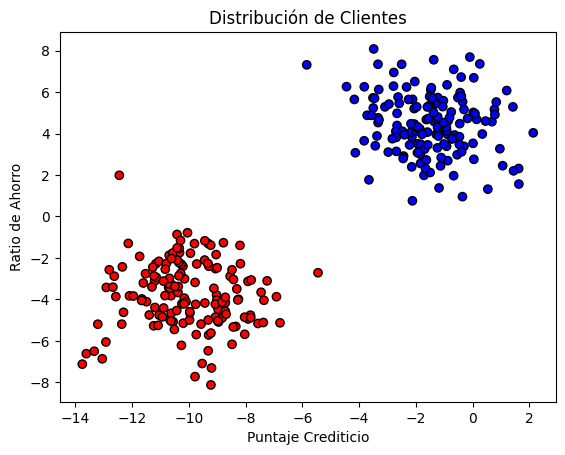

In [9]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.5, random_state=1)

# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

## Paso 2: Definición de la Arquitectura (Misión del Alumno)
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**Guía Técnica:**

* Usa una capa Dense.

* Como es un Perceptrón de una sola capa, units debe ser igual a 1.

* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [14]:
model = tf.keras.models.Sequential([
    # Define una capa Dense (completamente conectada)
    # units=1: Una sola neurona de salida, típica para clasificación binaria.
    # activation='sigmoid': La función de activación sigmoide comprime la salida entre 0 y 1,
    #                        interpretándose como una probabilidad.
    # input_shape=(2,): Indica que el modelo espera 2 características de entrada (Puntaje Crediticio y Ratio de Ahorro).
    tf.keras.layers.Dense(units=1, activation='sigmoid', input_shape=(2,))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Paso 3: Compilación del Sistema
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

**Ayuda Sugerida:**

* Para clasificación binaria, la pérdida estándar es binary_crossentropy.

* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

In [15]:
model.compile(
    # optimizer: Define cómo se ajustarán los pesos del modelo durante el entrenamiento.
    # tf.keras.optimizers.SGD: Usamos el Optimizador de Descenso de Gradiente Estocástico.
    # learning_rate=0.1: La tasa de aprendizaje, controla el tamaño de los pasos durante la optimización.
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    # loss: Mide qué tan bueno es el modelo en predecir la salida correcta.
    # 'binary_crossentropy': Función de pérdida estándar para problemas de clasificación binaria.
    loss='binary_crossentropy',
    # metrics: Métricas para evaluar el rendimiento del modelo durante el entrenamiento y la evaluación.
    # ['accuracy']: La precisión es una métrica común que indica la proporción de predicciones correctas.
    metrics=['accuracy']
)

## Paso 4: Entrenamiento y Regularización
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**Instrucciones:**

* Ejecuta el método .fit().

* Prueba configurar el entrenamiento con 50 épocas.

In [16]:
history = model.fit(
    # X: Los datos de entrada (características) para el entrenamiento.
    X,
    # y: Las etiquetas o clases objetivo para el entrenamiento (0 para Alto Riesgo, 1 para Bajo Riesgo).
    y,
    # epochs: El número de veces que el modelo iterará sobre todo el conjunto de datos de entrenamiento.
    epochs=50,
    # verbose=1: Muestra una barra de progreso para cada época durante el entrenamiento.
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9300 - loss: 0.1446  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9933 - loss: 0.0479 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9967 - loss: 0.0313 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0242 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0203 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0177 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0158 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0145 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0135 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0127 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0119 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

## Paso 5: Evaluación de Resultados
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step


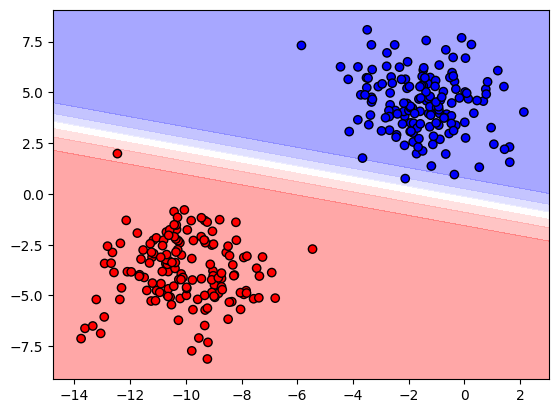

In [13]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

### Resultados de la Frontera de Decisión Inicial (make_blobs)

El primer gráfico de dispersión muestra los datos `make_blobs` originales, que son linealmente separables. La frontera de decisión (la línea que divide las dos regiones de color) generada por el perceptrón simple es una línea recta clara. Esta línea divide eficazmente los puntos rojos de los puntos azules, lo que indica que el modelo ha aprendido a clasificar correctamente a los clientes de 'Bajo Riesgo' (Clase 1) y 'Alto Riesgo' (Clase 0) en este conjunto de datos. La alta precisión observada durante el entrenamiento (`accuracy: 1.0000`) corrobora esta observación.

## Desafíos Extra
**Impacto del Sesgo:** Si imprimes los pesos del modelo con model.get_weights(), ¿cuál es el valor del Bias?

¿Qué pasaría si fuera cero?

**Regularización:** Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.

¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?

**No Linealidad:** Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.

### Desafío Extra 1: Impacto del Sesgo

Vamos a imprimir los pesos del modelo para ver el valor del Bias. En Keras, `model.get_weights()` devuelve una lista de arrays NumPy. Para una capa `Dense` simple, el primer array contiene los pesos (`kernel`) y el segundo array contiene el sesgo (`bias`).

In [17]:
weights, bias = model.get_weights()
print("Pesos (kernel):")
print(weights)
print("\nBias:")
print(bias)

# El bias es el término independiente que ajusta la línea de decisión.
# Si fuera cero, la línea de decisión siempre pasaría por el origen (0,0),
# lo que limitaría la capacidad del modelo para ajustarse a datos donde la frontera
# de decisión no pasa por el origen. Un bias distinto de cero permite que la
# frontera se desplace libremente en el espacio de características.

Pesos (kernel):
[[-0.43117085]
 [-1.6882521 ]]

Bias:
[-0.4507343]


### Desafío Extra 2: Regularización (L2)

Ahora, vamos a ver el efecto de la regularización L2. Para ello, crearemos un nuevo modelo con `kernel_regularizer='l2'` en la capa `Dense`. Esto añadirá un término de penalización a la función de pérdida proporcional al cuadrado de los pesos, lo que ayuda a evitar el sobreajuste y a mantener los pesos pequeños.

Después de definir el nuevo modelo, lo compilaremos, entrenaremos y visualizaremos su frontera de decisión.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenamiento del modelo con regularización L2 completado.
Visualizando frontera de decisión con regularización L2:
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


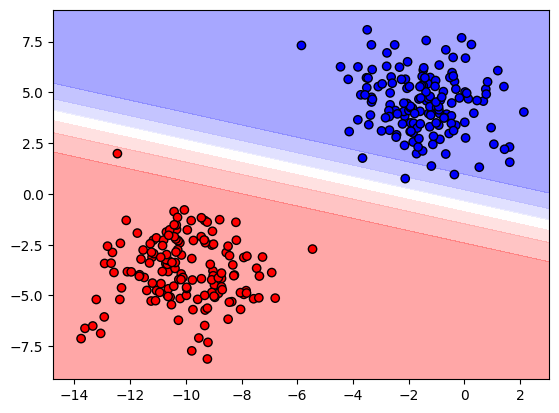


Pesos (kernel) con L2:
[[-0.3529335]
 [-1.1612138]]

Bias con L2:
[-0.6103489]


In [18]:
from tensorflow.keras import regularizers

# Definimos un nuevo modelo con regularización L2
model_l2 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=1, activation='sigmoid', input_shape=(2,), kernel_regularizer=regularizers.l2(0.01))
])

# Compilamos el nuevo modelo
model_l2.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el nuevo modelo
history_l2 = model_l2.fit(X, y, epochs=50, verbose=0) # verbose=0 para no imprimir cada época

print("Entrenamiento del modelo con regularización L2 completado.")

# Visualizamos la frontera de decisión del modelo con L2
print("Visualizando frontera de decisión con regularización L2:")
plot_frontier(X, y, model_l2)

# Imprimimos los pesos del modelo con L2 para comparar
weights_l2, bias_l2 = model_l2.get_weights()
print("\nPesos (kernel) con L2:")
print(weights_l2)
print("\nBias con L2:")
print(bias_l2)

# Observaciones sobre la regularización L2:
# Comparado con el modelo original, es probable que los pesos (kernel) sean de menor magnitud.
# La frontera de decisión podría ser ligeramente 'más suave' o menos ajustada a los puntos extremos,
# indicando una menor tendencia al sobreajuste.

### Resultados de la Frontera de Decisión con Regularización L2

En este gráfico, observamos la frontera de decisión para el modelo entrenado con regularización L2. Aunque visualmente la frontera sigue siendo una línea recta (como es de esperar en un perceptrón simple), la regularización L2 tiende a hacer que los pesos del modelo sean más pequeños. Esto puede resultar en una frontera de decisión ligeramente 'más suave' o menos ajustada a puntos atípicos, lo que puede ayudar a reducir el sobreajuste en conjuntos de datos más complejos. En este caso de datos linealmente muy separables, el efecto visual puede no ser drástico, pero conceptualmente, la L2 busca una solución más generalizada al penalizar la complejidad del modelo.

### Desafío Extra 3: No Linealidad (make_moons)

Ahora, vamos a cambiar el generador de datos a `make_moons` para ver cómo se comporta el Perceptrón Simple con datos no linealmente separables. Un perceptrón de una sola capa solo puede encontrar una frontera de decisión lineal.

Volveremos a generar los datos, definiremos un nuevo perceptrón (sin regularización para esta prueba), lo entrenaremos y visualizaremos su frontera de decisión.

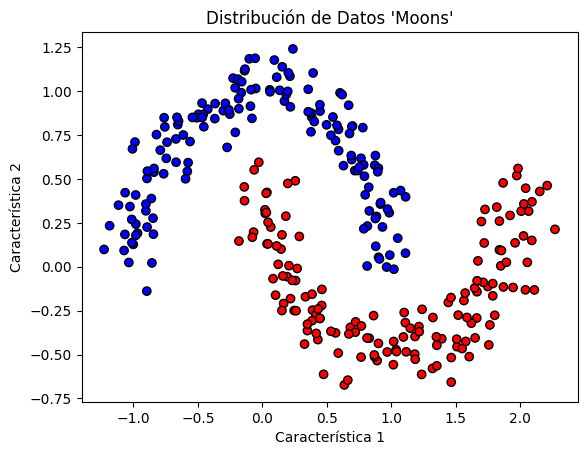

Entrenamiento del modelo con datos 'moons' completado.
Visualizando frontera de decisión con datos 'moons':
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


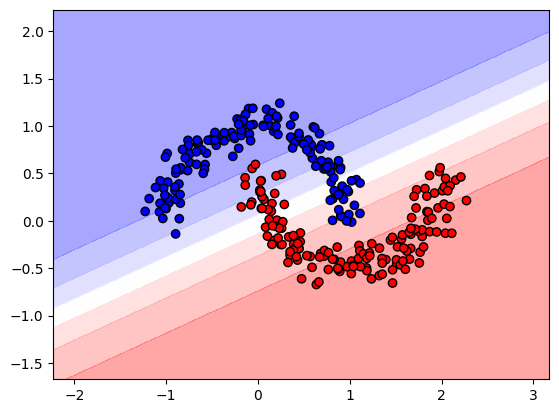

In [19]:
# Generamos nuevos datos con make_moons
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

# Visualización de los datos 'moons'
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='bwr', edgecolors='k')
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Distribución de Datos 'Moons'")
plt.show()

# Definimos un nuevo perceptrón para los datos 'moons' (sin L2)
model_moons = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=1, activation='sigmoid', input_shape=(2,))
])

# Compilamos el modelo
model_moons.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el modelo con los datos 'moons'
history_moons = model_moons.fit(X_moons, y_moons, epochs=50, verbose=0)

print("Entrenamiento del modelo con datos 'moons' completado.")

# Visualizamos la frontera de decisión para los datos 'moons'
print("Visualizando frontera de decisión con datos 'moons':")
plot_frontier(X_moons, y_moons, model_moons)

# Justificación:
# Como se puede observar en el gráfico, el Perceptrón de una sola capa
# NO es capaz de separar estos datos. La frontera de decisión es una línea recta,
# y los datos 'moons' no son linealmente separables. Esto es una limitación
# fundamental del Perceptrón Simple. Para separar estos datos, se necesitaría
# un modelo más complejo, como un Perceptrón Multicapa (MLP) con capas ocultas
# y funciones de activación no lineales.

### Resultados de la Frontera de Decisión con Datos 'make_moons' (No Linealidad)

El último gráfico de dispersión presenta los datos 'make_moons', que son un ejemplo clásico de datos no linealmente separables. Como se observa, el perceptrón simple intenta encontrar una frontera de decisión, pero esta es una línea recta. A pesar de los intentos del modelo, no es posible separar de forma efectiva las dos clases con una única línea recta. Esto ilustra una limitación fundamental del perceptrón simple: solo puede modelar relaciones lineales. Para clasificar datos con esta estructura no lineal, se necesitarían modelos más complejos, como redes neuronales con múltiples capas (MLP) y funciones de activación no lineales que permitan aprender fronteras de decisión curvas.